In [2]:
#Import model
from sklearn.ensemble import IsolationForest

In [4]:
import pandas as pd
import numpy as np

# Simulate intraday payment transaction data
np.random.seed(42)
n = 200

timestamps = pd.date_range('2024-01-15 08:00', periods=n, freq='3min')

transactions = pd.DataFrame({
    'timestamp': timestamps,
    'amount': np.random.choice(
        np.concatenate([np.random.uniform(1_000, 50_000, 180),
                        np.random.uniform(-50_000, -1_000, 20)]),
        size=n,
        replace=False
    )
})

print(f'Loaded {len(transactions)} transactions')
transactions.head()

Loaded 200 transactions


,timestamp,amount
0,2024-01-15 08:00:00,18564.820699
1,2024-01-15 08:03:00,46171.837516
2,2024-01-15 08:06:00,1812.803617
3,2024-01-15 08:09:00,2540.030099
4,2024-01-15 08:12:00,18480.913008


In [6]:
#Prepare Transaction Features
# Convert timestamp to datetime
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])

# Create 5-minute time buckets
transactions["time_bucket"] = transactions["timestamp"].dt.floor("5min")

# Define liquidity change
# positive = inflow, negative = outflow
transactions["liquidity_change"] = transactions["amount"]

transactions.head()

,timestamp,amount,time_bucket,liquidity_change
0,2024-01-15 08:00:00,18564.820699,2024-01-15 08:00:00,18564.820699
1,2024-01-15 08:03:00,46171.837516,2024-01-15 08:00:00,46171.837516
2,2024-01-15 08:06:00,1812.803617,2024-01-15 08:05:00,1812.803617
3,2024-01-15 08:09:00,2540.030099,2024-01-15 08:05:00,2540.030099
4,2024-01-15 08:12:00,18480.913008,2024-01-15 08:10:00,18480.913008


In [7]:
#Aggregate Liquidity Movements
liquidity = (
    transactions
    .groupby("time_bucket")["liquidity_change"]
    .sum()
    .reset_index()
)

In [8]:
#Calculate Liquidity Position
opening_liquidity = 500_000_000

liquidity["liquidity_position"] = (
    opening_liquidity + liquidity["liquidity_change"].cumsum()
)

liquidity.head()

,time_bucket,liquidity_change,liquidity_position
0,2024-01-15 08:00:00,64736.658215,5.000647e+08
1,2024-01-15 08:05:00,4352.833716,5.000691e+08
2,2024-01-15 08:10:00,18480.913008,5.000876e+08
3,2024-01-15 08:15:00,26079.685039,5.001137e+08
4,2024-01-15 08:20:00,4105.505025,5.001178e+08


In [9]:
# Train the Anomaly Detection Model
from sklearn.ensemble import IsolationForest

X = liquidity[["liquidity_change"]]

model = IsolationForest(
    contamination=0.05,
    random_state=42
)

model.fit(X)

liquidity["anomaly"] = model.predict(X)

In [10]:
#Extract Liquidity Anomalies
anomalies = liquidity[liquidity["anomaly"] == -1]

print("Detected liquidity anomalies:")
anomalies

Detected liquidity anomalies:


,time_bucket,liquidity_change,liquidity_position,anomaly
11,2024-01-15 08:55:00,-38149.237746,5.002723e+08,-1
25,2024-01-15 10:05:00,94767.629474,5.007329e+08,-1
54,2024-01-15 12:30:00,-23300.927816,5.017179e+08,-1
82,2024-01-15 14:50:00,-46842.281892,5.025301e+08,-1
85,2024-01-15 15:05:00,-36794.232881,5.025346e+08,-1
96,2024-01-15 16:00:00,91952.277903,5.030368e+08,-1


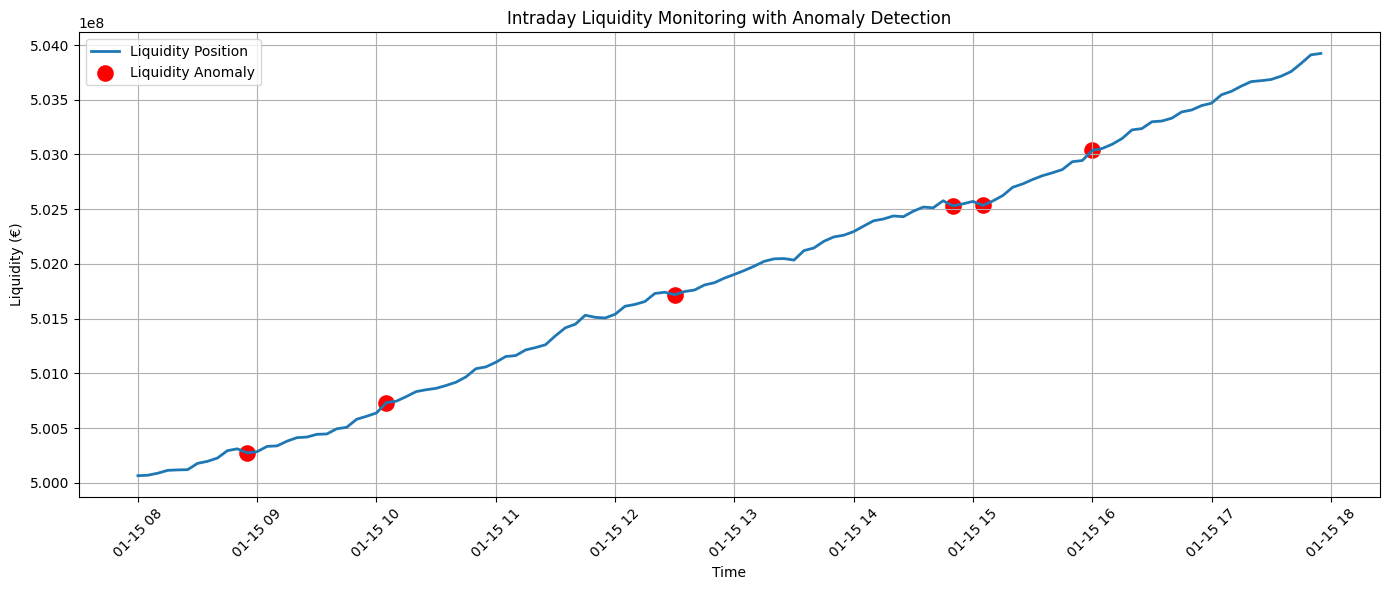

In [11]:
#Visualize Liquidity Position with Anomalies
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    liquidity["time_bucket"],
    liquidity["liquidity_position"],
    label="Liquidity Position",
    linewidth=2
)

plt.scatter(
    anomalies["time_bucket"],
    anomalies["liquidity_position"],
    color="red",
    s=120,
    label="Liquidity Anomaly"
)

plt.title("Intraday Liquidity Monitoring with Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("Liquidity (€)")

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The red points show time periods where the Isolation Forest model detected unusual liquidity movements.

These anomalies correspond to unusual transaction patterns, such as:

unusually large payments

sudden inflow or outflow spikes

transaction clusters outside normal behavior

In the chart, the anomalies occur at several points in the day, for example:

around 09:00

around 10:00

around 12:30

around 15:00

around 16:00

These represent time buckets where liquidity changes were significantly different from typical transaction behavior.